# Laboratorio 3 – Modelos de Regresión Lineal
## CC3074 – Minería de Datos | UVG Semestre I 2026

**Universidad del Valle de Guatemala**  
Facultad de Ingeniería — Departamento de Ciencias de la Computación

---

**Contexto:** SmartStay Advisors necesita estimar precios competitivos de propiedades Airbnb para optimizar la ocupación de sus clientes. El objetivo es construir y comparar modelos de regresión lineal que predigan el precio (`price`) de una propiedad a partir de sus características.

## 0. Importación de librerías

In [1]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga del Dataset

El dataset proviene de listados de Airbnb y está en formato `.RData`. Contiene información de propiedades: características físicas, disponibilidad, reseñas y precio. Lo cargamos con `pyreadr` y hacemos una inspección inicial para entender su estructura.

In [2]:
# Cargar el archivo .RData
result = pyreadr.read_r('data/listings.RData')
df = result[list(result.keys())[0]]

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(3)

Dataset cargado: 171,748 filas x 80 columnas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


In [3]:
# Tipos de datos por columna
print('=== Tipos de datos ===')
print(df.dtypes.value_counts())
print()

# Porcentaje de nulos por columna (solo las que tienen)
nulls = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nulls = nulls[nulls > 0]
print(f'=== Columnas con valores nulos ({len(nulls)} columnas) ===')
print(nulls.round(1).to_string())

=== Tipos de datos ===
str        37
int32      18
float64    15
object     10
Name: count, dtype: int64



=== Columnas con valores nulos (23 columnas) ===
calendar_updated                100.0
estimated_revenue_l365d          55.6
price                            52.0
neighbourhood_group_cleansed     29.5
review_scores_value              23.5
review_scores_location           23.5
review_scores_checkin            23.5
review_scores_accuracy           23.5
review_scores_communication      23.5
review_scores_cleanliness        23.5
reviews_per_month                23.5
review_scores_rating             23.5
beds                             18.4
bathrooms                        18.3
license                           6.1
bedrooms                          6.1
host_total_listings_count         0.5
host_listings_count               0.5
maximum_maximum_nights            0.0
maximum_minimum_nights            0.0
minimum_maximum_nights            0.0
minimum_minimum_nights            0.0
host_about                        0.0


## 2. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio nos permite entender la distribución de las variables, detectar outliers y descubrir relaciones entre las características y la variable objetivo (`price`). Organizamos el EDA en las siguientes etapas:

1. Limpieza de la variable objetivo
2. Distribución del precio
3. Variables numéricas y su correlación con el precio
4. Variables categóricas relevantes
5. Preprocesamiento

### 2.1 Limpieza de la variable objetivo: `price`

En datasets de Airbnb el precio suele venir como string con formato `"$120.00"`. Debemos convertirlo a numérico antes de cualquier análisis.

In [4]:
# Ver formato original
print('Tipo original:', df['price'].dtype)
print('Muestra:', df['price'].dropna().head(5).tolist())

Tipo original: str
Muestra: ['$97.00', '$160.00', '$38.00', '$145.00', '$58.00']


In [5]:
# Limpiar price: quitar '$' y ',' y convertir a float
df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Eliminar filas sin precio (no se puede entrenar sin la variable objetivo)
df = df.dropna(subset=['price']).copy()
print(f'Registros con precio válido: {len(df):,}')
print(df['price'].describe())

Registros con precio válido: 76,246
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64


### 2.2 Distribución del precio

Analizamos la distribución de `price` para detectar sesgo y outliers. Una distribución muy sesgada podría afectar los modelos de regresión.

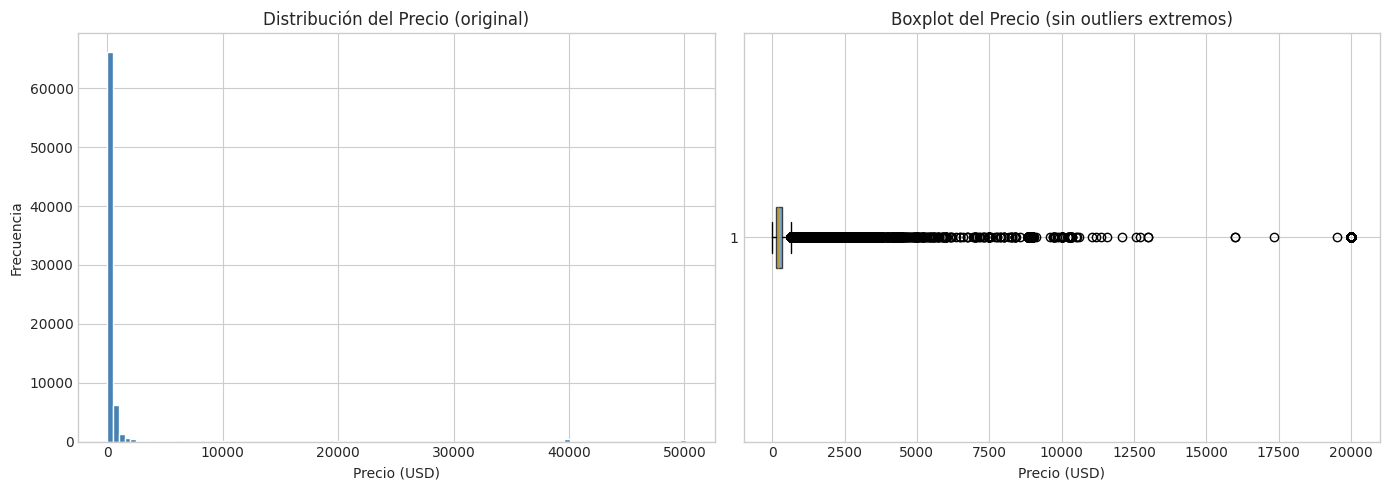

Sesgo (skewness): 9.87
Curtosis: 99.03
Precio mínimo: $8.00
Precio máximo: $50,123.00
Precio mediano: $193.00


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del precio original
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Precio (original)')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['price'].clip(upper=df['price'].quantile(0.99)),
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot del Precio (sin outliers extremos)')
axes[1].set_xlabel('Precio (USD)')

plt.tight_layout()
plt.show()

print(f'Sesgo (skewness): {df["price"].skew():.2f}')
print(f'Curtosis: {df["price"].kurt():.2f}')
print(f'Precio mínimo: ${df["price"].min():.2f}')
print(f'Precio máximo: ${df["price"].max():,.2f}')
print(f'Precio mediano: ${df["price"].median():.2f}')

### 2.3 Transformación logarítmica del precio

Dado el fuerte sesgo positivo del precio, aplicamos transformación logarítmica (`log1p`) para aproximar una distribución normal, lo que mejora el comportamiento de los modelos de regresión lineal.

Registros tras filtrar outliers extremos: 75,531


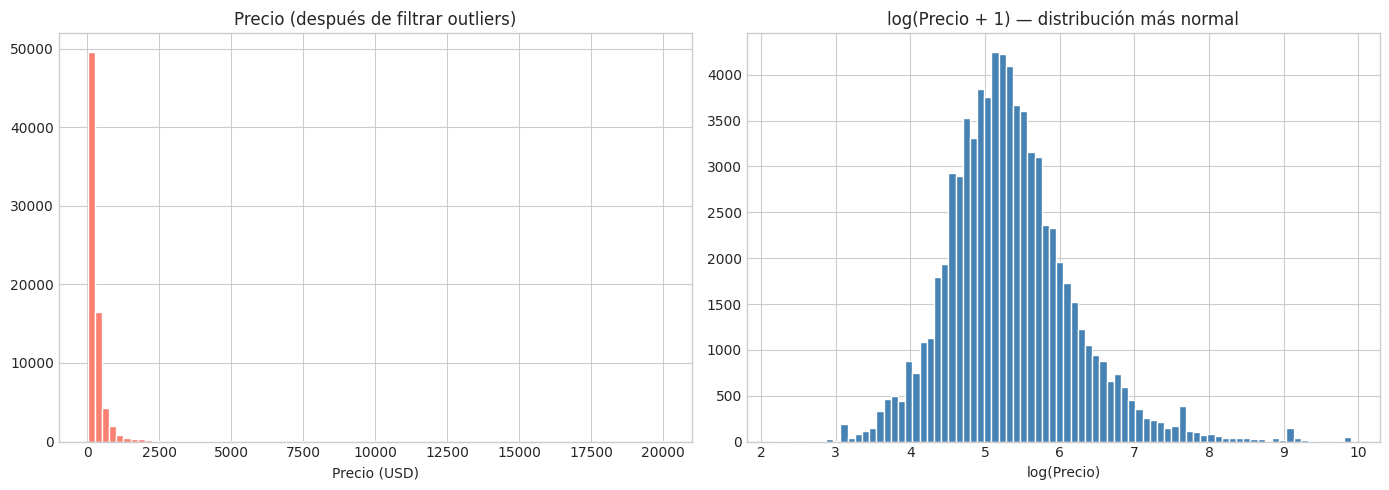

Sesgo log_price: 0.832


In [7]:
# Filtrar outliers extremos antes de modelar (precio > 0 y < percentil 99)
p99 = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= p99)].copy()
print(f'Registros tras filtrar outliers extremos: {len(df):,}')

# Transformación log
df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=80, color='salmon', edgecolor='white')
axes[0].set_title('Precio (después de filtrar outliers)')
axes[0].set_xlabel('Precio (USD)')

axes[1].hist(df['log_price'], bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('log(Precio + 1) — distribución más normal')
axes[1].set_xlabel('log(Precio)')

plt.tight_layout()
plt.show()

print(f'Sesgo log_price: {df["log_price"].skew():.3f}')

### 2.4 Variables numéricas y correlación con el precio

Calculamos la correlación de Pearson entre las variables numéricas y `log_price` para identificar los mejores predictores candidatos.

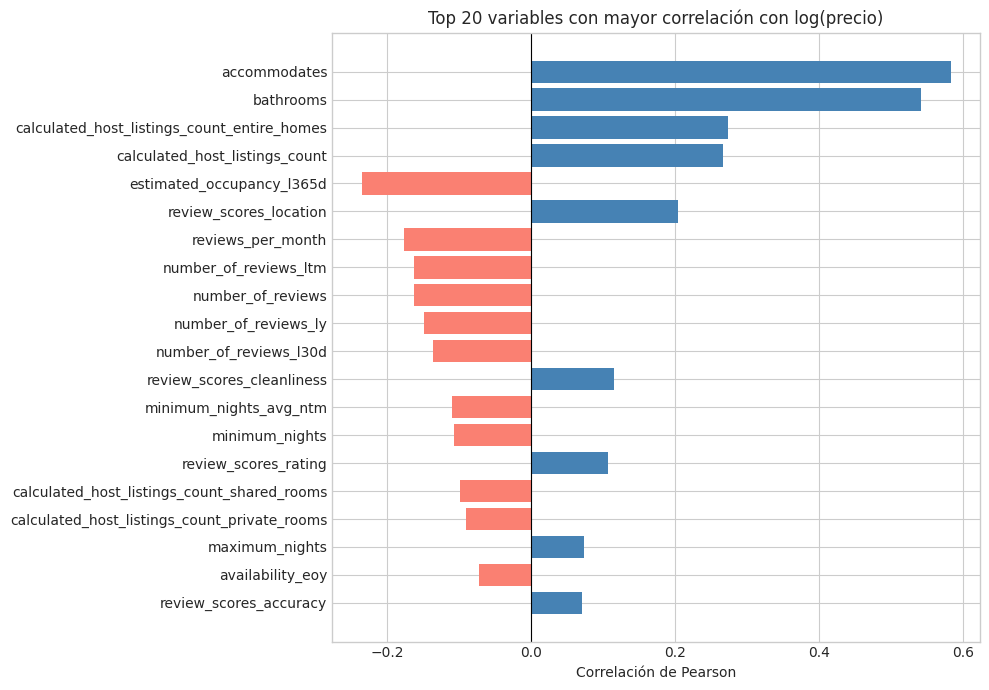

Top 10 correlaciones:
accommodates                                   0.583
bathrooms                                      0.541
calculated_host_listings_count_entire_homes    0.273
calculated_host_listings_count                 0.267
estimated_occupancy_l365d                     -0.236
review_scores_location                         0.203
reviews_per_month                             -0.177
number_of_reviews_ltm                         -0.163
number_of_reviews                             -0.163
number_of_reviews_ly                          -0.149


In [8]:
# Seleccionar columnas numéricas relevantes (excluir IDs, coordenadas puras, etc.)
exclude_cols = ['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'price', 'log_price']
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols]

# Correlación con log_price
corr_with_price = df[num_cols + ['log_price']].corr()['log_price'].drop('log_price')
corr_with_price = corr_with_price.sort_values(key=abs, ascending=False)

# Visualizar top 20
top20 = corr_with_price.head(20)
plt.figure(figsize=(10, 7))
colors = ['steelblue' if v >= 0 else 'salmon' for v in top20.values]
plt.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 variables con mayor correlación con log(precio)')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('Top 10 correlaciones:')
print(corr_with_price.head(10).round(3).to_string())

### 2.5 Variables categóricas relevantes

Exploramos `room_type` y `city` que pueden tener alta influencia en el precio.

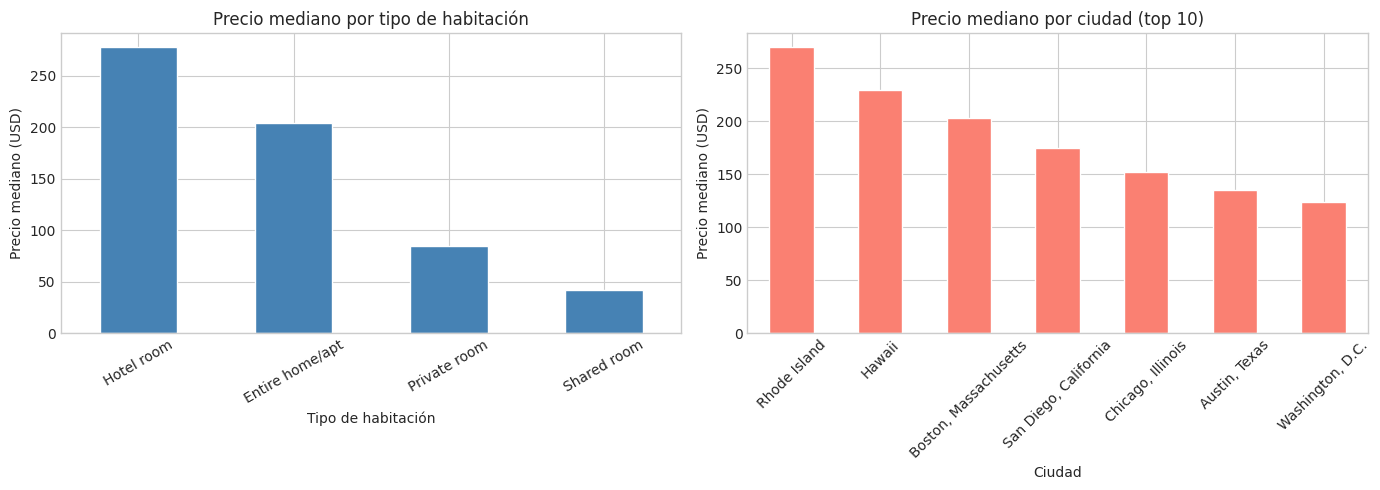

Distribución room_type:
room_type
Entire home/apt    65479
Private room        9547
Hotel room           290
Shared room          215
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precio promedio por tipo de habitación
rt_mean = df.groupby('room_type')['price'].median().sort_values(ascending=False)
rt_mean.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Precio mediano por tipo de habitación')
axes[0].set_xlabel('Tipo de habitación')
axes[0].set_ylabel('Precio mediano (USD)')
axes[0].tick_params(axis='x', rotation=30)

# Precio promedio por ciudad (top 10)
city_mean = df.groupby('city')['price'].median().sort_values(ascending=False).head(10)
city_mean.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Precio mediano por ciudad (top 10)')
axes[1].set_xlabel('Ciudad')
axes[1].set_ylabel('Precio mediano (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Distribución room_type:')
print(df['room_type'].value_counts())

### 2.6 Preprocesamiento

Antes de modelar realizamos:
- Eliminar columnas con >50% de nulos (aportan ruido)
- Imputar medianas en numéricas, moda en categóricas
- Codificar variables categóricas relevantes con one-hot encoding

In [10]:
# 1. Eliminar columnas con >50% nulos
thresh = 0.5 * len(df)
df_clean = df.dropna(thresh=int(thresh), axis=1).copy()
print(f'Columnas eliminadas por >50% nulos: {df.shape[1] - df_clean.shape[1]}')
print(f'Columnas restantes: {df_clean.shape[1]}')

# 2. Imputar nulos en numéricas con mediana
num_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols_clean:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3. Codificar room_type (alta correlación con precio)
df_clean = pd.get_dummies(df_clean, columns=['room_type'], drop_first=True, dtype=int)

print('Preprocesamiento completado.')
print(f'Shape final: {df_clean.shape}')

Columnas eliminadas por >50% nulos: 2
Columnas restantes: 79


Preprocesamiento completado.
Shape final: (75531, 81)
